# Admixture Mapping

Admixture mapping tests whether local ancestry at a genomic region is associated with a phenotype in recently admixed individuals. Instead of asking whether a specific SNP allele is associated with a trait, we ask whether carrying ancestry from a source population at a local genomic window changes trait values after accounting for background ancestry and other covariates.

This tutorial, we build a synthetic local ancestry dataset with a quantitative trait, run `snputils.tools.run_admixture_mapping`, and make a Manhattan plot from the resulting association table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from snputils.datasets import build_synthetic_admixture_dataset
from snputils.phenotype.genobj import CovariateObject, PhenotypeObject
from snputils.tools import run_admixture_mapping
from snputils.visualization import manhattan_plot, qq_plot


## What the input represents

A local ancestry inference method usually produces one ancestry label per haplotype per genomic window. For a diploid sample, each window therefore has two ancestry labels: one for each haplotype. `snputils` stores that information in a `LocalAncestryObject`.

For each ancestry and each window, admixture mapping converts those two haplotype labels into an ancestry dosage: 0, 1, or 2 copies of the requested ancestry. The association model then tests whether that dosage is related to the phenotype.

## Build a synthetic dataset

The synthetic trait below has a few sparse local ancestry effects plus global ancestry-like covariates, so the strongest signals should appear near the simulated causal windows while most tests remain null.

`build_synthetic_admixture_dataset` lives in `snputils.datasets`, and returns:

- `laiobj`: local ancestry calls for each haplotype and window.
- `phenotype`: a continuous trait generated from a few local ancestry effects, covariates, and noise.
- `covar_matrix`: covariates that include genome-wide ancestry-like summaries.
- `effect_windows`, `effect_ancestries`, and `effect_sizes`: the simulated ground truth used only for interpretation.


In [22]:
RESULTS_DIR = Path("results/admixture_mapping")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PHENO_NAME = "TRAIT"

synthetic = build_synthetic_admixture_dataset(
    n_samples=2000,
    n_windows=2200,
    n_covariates=3,
    seed=42,
)

laiobj = synthetic["laiobj"]
sample_ids = synthetic["sample_ids"]
phenotype_values = synthetic["phenotype"]
covar_names = synthetic["covar_names"]
covar_matrix = synthetic["covar_matrix"]
covariates = synthetic["covariates"]

print(laiobj)
print(f"Phenotype shape: {phenotype_values.shape}")
print(f"Covariate matrix shape: {covar_matrix.shape}")

LocalAncestryObject(shape=(2200, 4000), n_windows=2200, n_samples=2000, n_haplotypes=4000, n_ancestries=3, has_window_metadata=True, has_ancestry_map=True)
Phenotype shape: (2000,)
Covariate matrix shape: (2000, 3)


The simulated causal windows are shown below. In real data these columns do not exist; they are included here so we can sanity-check whether the analysis recovers the planted signal.


In [23]:
truth = pd.DataFrame({
    "window_index_0_based": synthetic["effect_windows"],
    "chromosome": laiobj.chromosomes[synthetic["effect_windows"]],
    "start": laiobj.physical_pos[synthetic["effect_windows"], 0],
    "end": laiobj.physical_pos[synthetic["effect_windows"], 1],
    "ancestry_code": synthetic["effect_ancestries"],
    "ancestry": [laiobj.ancestry_map[str(code)] for code in synthetic["effect_ancestries"]],
    "effect_size": synthetic["effect_sizes"],
})
truth

,window_index_0_based,chromosome,start,end,ancestry_code,ancestry,effect_size
0,220,3,500001,504999,0,AFR,0.30
1,1209,13,225001,229999,1,EUR,-0.26
2,2199,22,2475001,2479999,2,NAT,0.22


## Create phenotype and covariate inputs

`run_admixture_mapping` accepts file paths or in-memory snputils objects. Here we use an in-memory `PhenotypeObject`, `LocalAncestryObject`, and `CovariateObject`.

Covariates are important in real admixture mapping. Local ancestry is correlated across the genome and with global ancestry; without adjustment, a local window can look associated because it tags broader ancestry structure rather than a region-specific effect.

In [24]:
phenotype = PhenotypeObject(
    samples=sample_ids,
    values=phenotype_values,
    phenotype_name=PHENO_NAME,
    quantitative=True,
)

covariates = CovariateObject(
    samples=sample_ids,
    values=covar_matrix,
    covariate_names=covar_names,
)

pd.DataFrame(covariates.values, index=covariates.samples, columns=covariates.covariate_names)


,COV1,COV2,COV3
A00000,-0.592026,1.202679,-1.814628
A00001,-0.466538,0.707660,1.009263
A00002,0.111008,-0.569487,-1.621603
A00003,-0.771943,1.456788,-0.827295
A00004,0.377103,0.118588,1.263990
...,...,...,...
A01995,-1.009311,0.402399,0.926203
A01996,-1.077347,2.266969,-2.301846
A01997,1.247959,-1.143709,2.716574
A01998,-0.652502,0.311645,-0.454804


## Run admixture mapping

The API uses `lai_source` for either an MSP path or a `LocalAncestryObject`.

For a quantitative trait, `snputils` fits a linear model per window and ancestry. For a binary trait, it fits a logistic model. The returned table includes p-values, effect estimates, standard errors, test type, ancestry labels, chromosome, position, and multiple-testing adjusted p-values when `adjust=True`.

In [25]:
results_path = RESULTS_DIR / "synthetic_admixture_mapping.tsv.gz"

results = run_admixture_mapping(
    phe_path=phenotype,
    lai_source=laiobj,
    results_path=results_path,
    batch_size=256,
    quantitative=True,
    covar=covariates,
    covar_variance_standardize=True,
    ci=0.95,
    adjust=True,
    keep_hla=True,
    return_results=True,
    verbose=True,
)

results

Reading LAI source (LocalAncestryObject)...
  Chunk 0: 256 windows (total so far: 256)
  Done. Processed 2,200 windows.


,#CHROM,POS,END,ID,REF,ALT,A1,ANCESTRY,TEST,OBS_CT,BETA,SE,T_STAT,P,L95,U95,BONF,FDR_BH,ERRCODE
0,1,1,4999,w1_AFR,N,AFR,AFR,AFR,LINEAR,2000,0.023002,0.082065,0.280291,0.779284,-0.137940,0.183944,1.000000,0.972639,.
1,1,25001,29999,w2_AFR,N,AFR,AFR,AFR,LINEAR,2000,0.047480,0.083229,0.570466,0.568426,-0.115746,0.210705,1.000000,0.928847,.
2,1,50001,54999,w3_AFR,N,AFR,AFR,AFR,LINEAR,2000,0.040931,0.083495,0.490217,0.624034,-0.122816,0.204677,1.000000,0.945408,.
3,1,75001,79999,w4_AFR,N,AFR,AFR,AFR,LINEAR,2000,0.037587,0.083946,0.447756,0.654378,-0.127044,0.202219,1.000000,0.949625,.
4,1,100001,104999,w5_AFR,N,AFR,AFR,AFR,LINEAR,2000,0.029027,0.084046,0.345373,0.729851,-0.135800,0.193855,1.000000,0.963429,.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,22,2375001,2379999,w2196_NAT,N,NAT,NAT,NAT,LINEAR,2000,0.407704,0.098221,4.150897,0.000035,0.215078,0.600330,0.227770,0.008760,.
6596,22,2400001,2404999,w2197_NAT,N,NAT,NAT,NAT,LINEAR,2000,0.366866,0.097521,3.761921,0.000173,0.175613,0.558120,1.000000,0.028631,.
6597,22,2425001,2429999,w2198_NAT,N,NAT,NAT,NAT,LINEAR,2000,0.351331,0.097945,3.587020,0.000343,0.159245,0.543416,1.000000,0.045085,.
6598,22,2450001,2454999,w2199_NAT,N,NAT,NAT,NAT,LINEAR,2000,0.372580,0.098086,3.798513,0.000150,0.180219,0.564941,0.989492,0.027486,.


## Inspect the result table

Each row is one ancestry-specific test at one local ancestry window. `P` is the nominal association p-value. `BETA` is the estimated change in the quantitative trait per additional copy of that local ancestry, after covariate adjustment.

In [26]:
result_cols = [
    "#CHROM", "POS", "ID", "ANCESTRY", "TEST", "OBS_CT", "BETA", "SE", "P", "ERRCODE"
]
optional_cols = ["L95", "U95", "BONF", "FDR_BH"]
show_cols = [col for col in result_cols + optional_cols if col in results.columns]

results[show_cols].sort_values("P").head(10)


,#CHROM,POS,ID,ANCESTRY,TEST,OBS_CT,BETA,SE,P,ERRCODE,L95,U95,BONF,FDR_BH
221,3,525001,w222_AFR,AFR,LINEAR,2000,0.461419,0.085427,7.405491e-08,.,0.293883,0.628955,0.000489,0.000410
220,3,500001,w221_AFR,AFR,LINEAR,2000,0.451762,0.085136,1.242478e-07,.,0.284798,0.618726,0.000820,0.000410
219,3,475001,w220_AFR,AFR,LINEAR,2000,0.429493,0.085079,4.866634e-07,.,0.262639,0.596346,0.003212,0.000742
218,3,450001,w219_AFR,AFR,LINEAR,2000,0.427769,0.084760,4.900009e-07,.,0.261541,0.593996,0.003234,0.000742
215,3,375001,w216_AFR,AFR,LINEAR,2000,0.425320,0.084723,5.622006e-07,.,0.259166,0.591475,0.003711,0.000742
217,3,425001,w218_AFR,AFR,LINEAR,2000,0.418159,0.084661,8.496916e-07,.,0.252125,0.584192,0.005608,0.000935
216,3,400001,w217_AFR,AFR,LINEAR,2000,0.414282,0.084625,1.059287e-06,.,0.248320,0.580245,0.006991,0.000999
222,3,550001,w223_AFR,AFR,LINEAR,2000,0.407888,0.085471,1.954004e-06,.,0.240267,0.575509,0.012896,0.001612
3511,13,175001,w1208_EUR,EUR,LINEAR,2000,-0.408051,0.086594,2.619527e-06,.,-0.577876,-0.238226,0.017289,0.001902
223,3,575001,w224_AFR,AFR,LINEAR,2000,0.400049,0.085253,2.881959e-06,.,0.232856,0.567242,0.019021,0.001902


## Manhattan plot

A Manhattan plot places association strength along genomic position. Each point is a window-ancestry test. Taller points have smaller p-values. The dashed line is a Bonferroni threshold, a strict correction that divides the chosen significance level by the number of tests.


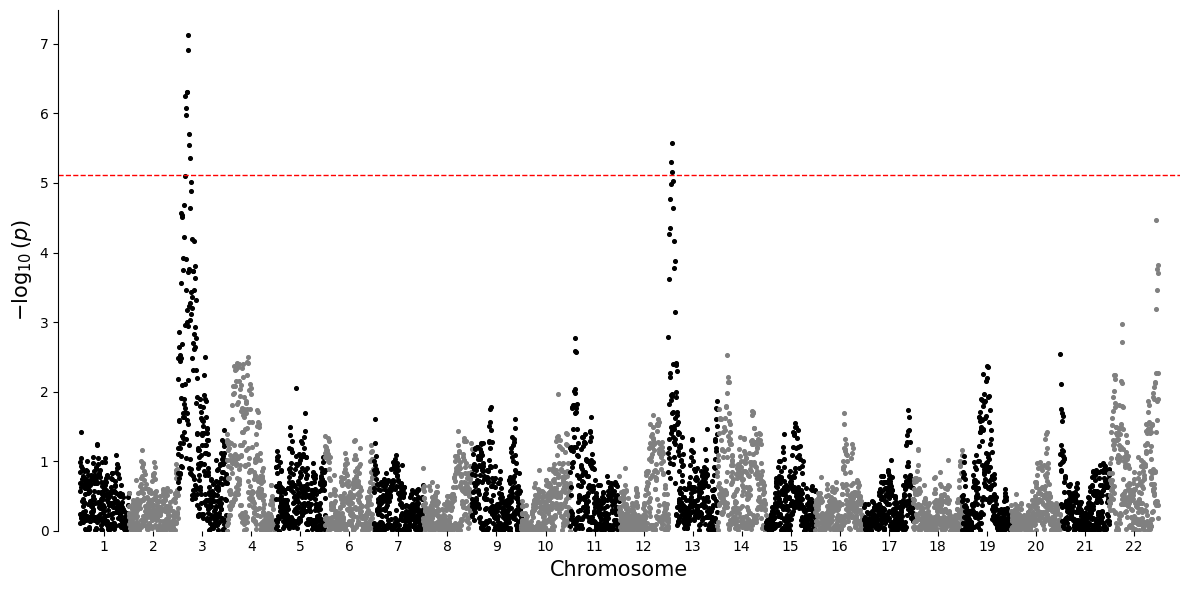

In [32]:
plot_df = results.loc[results["P"].notna() & (results["P"] > 0), ["#CHROM", "POS", "P", "ANCESTRY"]].copy()
plot_df["#CHROM"] = plot_df["#CHROM"]
plot_df["POS"] = plot_df["POS"]

manhattan_plot(plot_df)